In [1]:
import numpy as np 
from causal_graph_comparison import *

Detected non-Linux system, using scratch directory:  /Users/cisaicu/dev/mila/scratch


In [2]:
data_dir = f"{SCRATCH_DIR}/data/SAVAR_DATA_TEST"

In [ ]:
modes = 4
difficulty = "med_easy" # "easy", "med_easy", "med_hard", "hard"
seed = 1

file_name = f"modes_{modes}_difficulty_{difficulty}_noisestrength_0.2_seasonality_False_overlap_False"

In [ ]:
weights = np.load(f'{data_dir}/{file_name}_weights.npy')
modes = np.load(f'{data_dir}/{file_name}_modes.npy')
modes_noise = np.load(f'{data_dir}/{file_name}_noise_modes.npy')
parameters = np.load(f'{data_dir}/{file_name}_parameters.npy', allow_pickle=True)
data = np.load(f'{data_dir}/{file_name}.npy')

In [8]:
print("Data shape: ", data.shape)
print("Parameters shape: ", parameters.shape)
print("Modes shape: ", modes.shape)
print("Modes noise shape: ", modes_noise.shape)
print("Weights shape: ", weights.shape)

Data shape:  (1600, 10000)
Parameters shape:  ()
Modes shape:  (40, 40)
Modes noise shape:  (40, 40)
Weights shape:  (4, 40, 40)


In [8]:
parameters

array({'name': 'modes_4_tl_10000_isforced_False_difficulty_med_easy_noisestrength_0.2_seasonality_False_overlap_False', 'nx': 40, 'ny': 40, 'T': 10000, 'N': 4, 'links_coeffs': {0: [((0, -2), 0.5), ((2, -4), 0.48)], 1: [((1, -2), 0.17), ((0, -4), 0.28)], 2: [((2, -3), 0.29), ((0, -5), 0.36)], 3: [((3, -3), 0.17), ((2, -5), 0.68)]}},
      dtype=object)

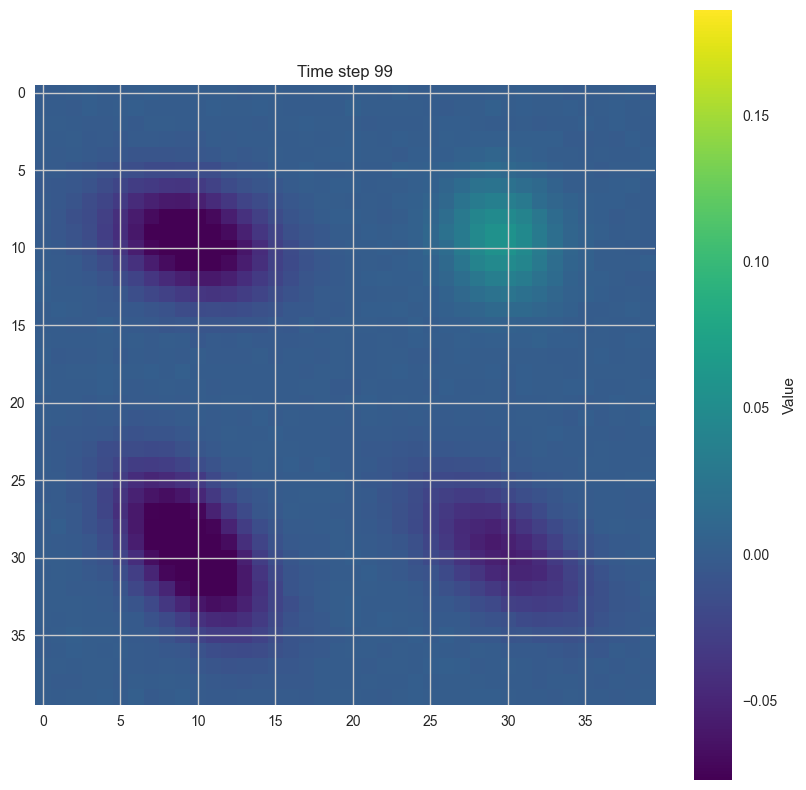

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# Reshape the data
# data_reshaped = data.reshape(20, 20, 10000)
# data_reshaped = data.reshape(30, 30, 10000)
data_reshaped = data.reshape(20, 20, 10000)
data_reshaped = data_reshaped[:,:,:100]

# Create the figure and axis
fig, ax = plt.subplots(figsize=(5, 5))

# Create the initial image
im = ax.imshow(data_reshaped[:, :, 0], cmap='viridis')
plt.colorbar(im, ax=ax, label='Value')

# Function to update the image for each frame
def update(frame):
    im.set_array(data_reshaped[:, :, frame])
    ax.set_title(f'Time step {frame}')
    return [im]

# Create the animation
ani = animation.FuncAnimation(fig, update, frames=range(0, 10000, 100), 
                            interval=100, blit=True)

# Save the animation to a file
ani.save('evolution_animation.gif', writer='pillow', fps=8)

# If you want to display it in the notebook
from IPython.display import HTML
HTML(ani.to_jshtml())

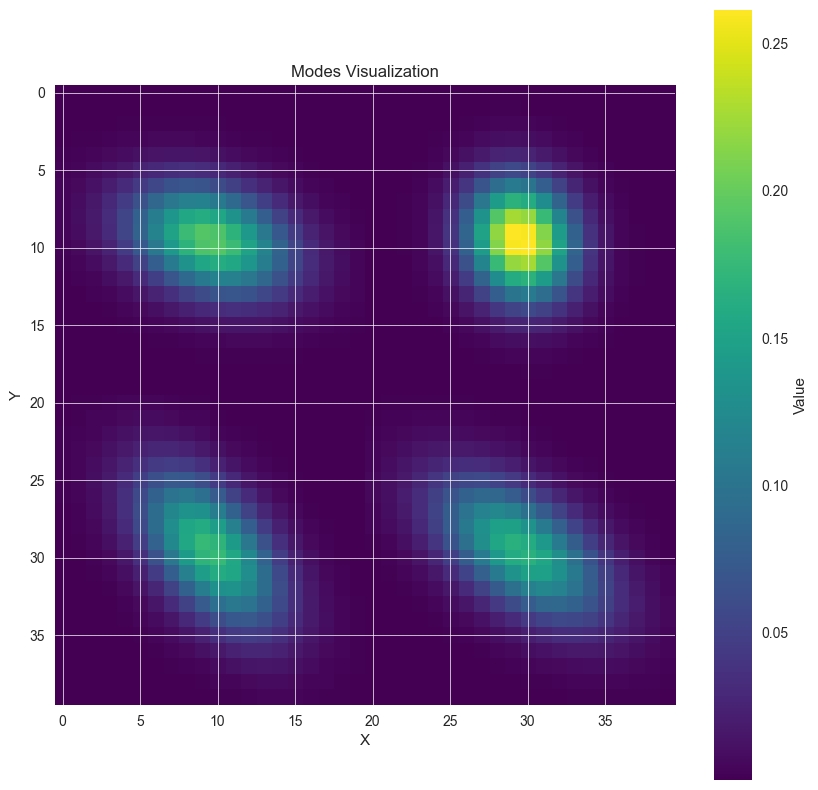

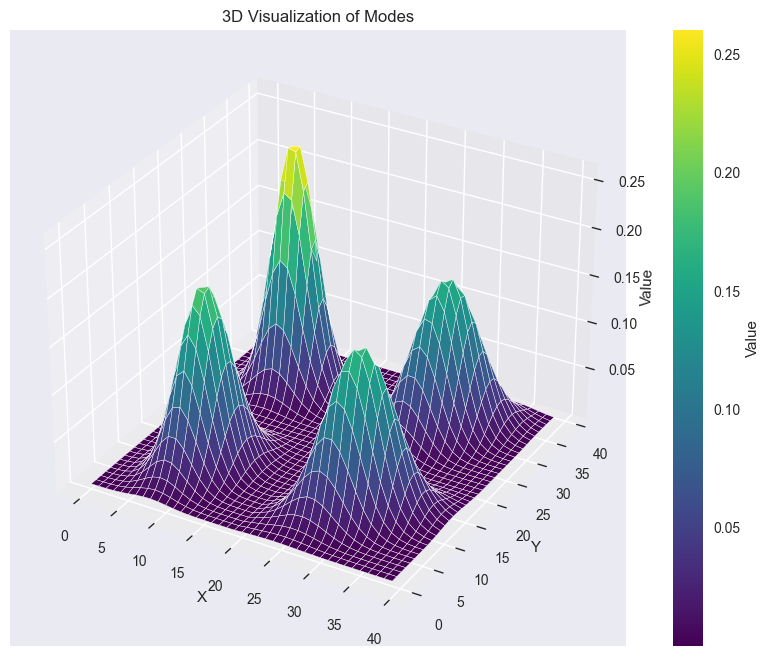

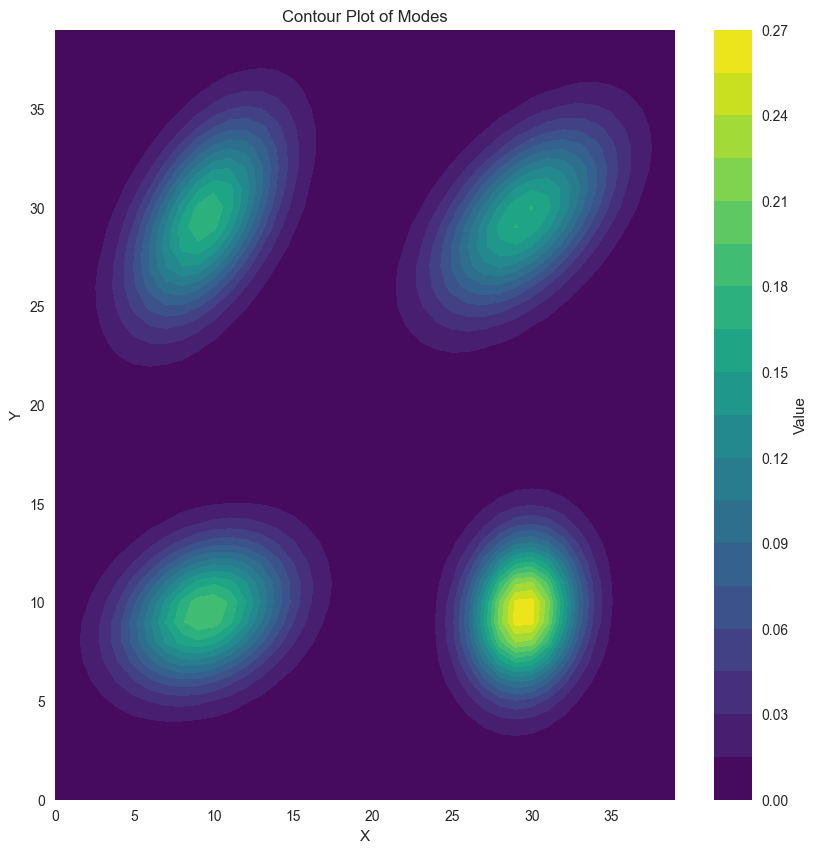

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# Create a figure with a larger size
plt.figure(figsize=(10, 10))

# Plot the modes as a heatmap
plt.imshow(modes, cmap='viridis')
plt.colorbar(label='Value')
plt.title('Modes Visualization')
plt.xlabel('X')
plt.ylabel('Y')

# Add grid lines to make it easier to see the structure
plt.grid(True, which='both', color='white', linewidth=0.5)

plt.show()

# Create a 3D surface plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Create coordinate matrices
x = np.arange(modes.shape[0])
y = np.arange(modes.shape[1])
X, Y = np.meshgrid(x, y)

# Plot the surface
surf = ax.plot_surface(X, Y, modes.T, cmap='viridis')

# Add a color bar
fig.colorbar(surf, ax=ax, label='Value')

# Set labels and title
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Value')
ax.set_title('3D Visualization of Modes')

plt.show()

# See the modes as a contour plot
plt.figure(figsize=(10, 10))
contour = plt.contourf(modes, levels=20, cmap='viridis')
plt.colorbar(contour, label='Value')
plt.title('Contour Plot of Modes')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()